In [4]:
import zipfile
import os
import shutil

zip_path = "/content/credit-card-segmentation.v1i.coco-segmentation.zip"
extract_path = "/content/project/coco_dataset"

if os.path.exists(extract_path):
    shutil.rmtree(extract_path)

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(" Dataset extracted successfully")

✅ Dataset extracted successfully


In [5]:
import os
import torch
import numpy as np
import cv2
from torch.utils.data import Dataset, DataLoader
from pycocotools.coco import COCO
import torch.nn as nn
import matplotlib.pyplot as plt

class COCOSegmentationDataset(Dataset):
    def __init__(self, images_dir, annotation_file):
        self.images_dir = images_dir
        self.coco = COCO(annotation_file)
        self.ids = list(self.coco.imgs.keys())

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, index):
        img_id = self.ids[index]
        img_info = self.coco.loadImgs(img_id)[0]
        img_path = os.path.join(self.images_dir, img_info['file_name'])

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        ann_ids = self.coco.getAnnIds(imgIds=img_id)
        anns = self.coco.loadAnns(ann_ids)

        mask = np.zeros((img_info['height'], img_info['width']), dtype=np.uint8)

        for ann in anns:
            mask = np.maximum(mask, self.coco.annToMask(ann))

        # Resize to 512 for inference
        image = cv2.resize(image, (512, 512))
        mask = cv2.resize(mask, (512, 512), interpolation=cv2.INTER_NEAREST)

        image = torch.tensor(image, dtype=torch.float32).permute(2,0,1) / 255.0
        mask = torch.tensor(mask, dtype=torch.float32).unsqueeze(0)

        return image, mask

In [6]:
val_dataset = COCOSegmentationDataset(
    "/content/project/coco_dataset/valid",
    "/content/project/coco_dataset/valid/_annotations.coco.json"
)

val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False)

print("Validation samples:", len(val_dataset))

loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Validation samples: 9


In [7]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self):
        super(UNet, self).__init__()

        self.down1 = DoubleConv(3, 64)
        self.pool1 = nn.MaxPool2d(2)

        self.down2 = DoubleConv(64, 128)
        self.pool2 = nn.MaxPool2d(2)

        self.down3 = DoubleConv(128, 256)
        self.pool3 = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(256, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.conv3 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.conv2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.conv1 = DoubleConv(128, 64)

        self.final = nn.Conv2d(64, 1, kernel_size=1)

    def forward(self, x):
        d1 = self.down1(x)
        p1 = self.pool1(d1)

        d2 = self.down2(p1)
        p2 = self.pool2(d2)

        d3 = self.down3(p2)
        p3 = self.pool3(d3)

        bn = self.bottleneck(p3)

        up3 = self.up3(bn)
        merge3 = torch.cat([up3, d3], dim=1)
        c3 = self.conv3(merge3)

        up2 = self.up2(c3)
        merge2 = torch.cat([up2, d2], dim=1)
        c2 = self.conv2(merge2)

        up1 = self.up1(c2)
        merge1 = torch.cat([up1, d1], dim=1)
        c1 = self.conv1(merge1)

        return self.final(c1)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UNet().to(device)
model.load_state_dict(torch.load("/content/final_unet_model.pth", map_location=device))
model.eval()

print(" Saved model loaded successfully")

✅ Saved model loaded successfully


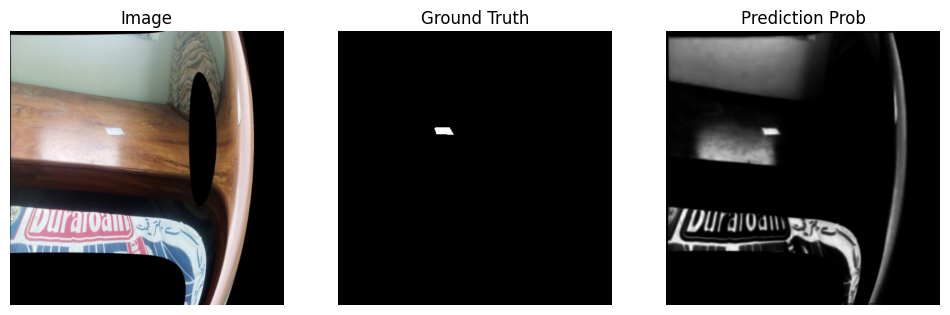

In [8]:
# Get one validation sample
images, masks = next(iter(val_loader))

images = images.to(device)
masks = masks.to(device)

with torch.no_grad():
    outputs = model(images)
    prob_map = torch.sigmoid(outputs)[0][0].cpu().numpy()

# Convert image back for display
image_np = images[0].cpu().permute(1,2,0).numpy()

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Image")
plt.imshow(image_np)
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Ground Truth")
plt.imshow(masks[0][0].cpu(), cmap="gray")
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Prediction Prob")
plt.imshow(prob_map, cmap="gray")
plt.axis("off")

plt.show()

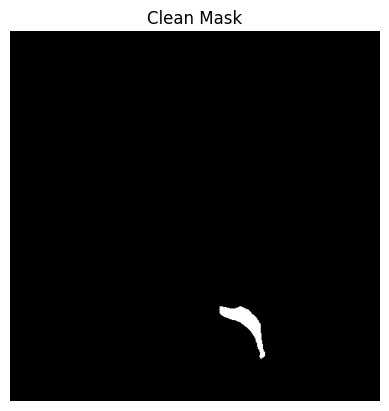

In [9]:
# Convert probability map to binary mask
threshold = 0.2
binary_mask = (prob_map > threshold).astype(np.uint8)

# Convert to 0–255
binary_mask_uint8 = binary_mask * 255

# Find contours
contours, _ = cv2.findContours(binary_mask_uint8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Keep largest contour
largest_contour = max(contours, key=cv2.contourArea)

# Draw clean mask
clean_mask = np.zeros_like(binary_mask_uint8)
cv2.drawContours(clean_mask, [largest_contour], -1, 255, -1)

plt.imshow(clean_mask, cmap="gray")
plt.title("Clean Mask")
plt.axis("off")
plt.show()

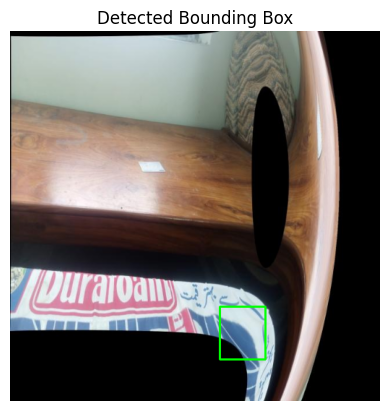

Pixel Width: 63
Pixel Height: 73


In [10]:
# Get bounding rectangle
x, y, w, h = cv2.boundingRect(largest_contour)

# Draw bounding box on resized image
resized_image = cv2.resize(image_np, (512, 512))
image_with_box = resized_image.copy()

cv2.rectangle(image_with_box, (x, y), (x+w, y+h), (0, 255, 0), 2)

plt.imshow(image_with_box)
plt.title("Detected Bounding Box")
plt.axis("off")
plt.show()

print("Pixel Width:", w)
print("Pixel Height:", h)

In [11]:
# Real credit card dimensions (mm)
real_width_mm = 85.6
real_height_mm = 53.98

# Determine long and short sides
pixel_long = max(w, h)
pixel_short = min(w, h)

real_long = max(real_width_mm, real_height_mm)
real_short = min(real_width_mm, real_height_mm)

# Compute pixel-to-mm ratio using long side
pixels_per_mm = pixel_long / real_long

predicted_long_mm = pixel_long / pixels_per_mm
predicted_short_mm = pixel_short / pixels_per_mm

print("Predicted Long Side (mm):", predicted_long_mm)
print("Predicted Short Side (mm):", predicted_short_mm)

print("Ground Truth Long (mm):", real_long)
print("Ground Truth Short (mm):", real_short)

Predicted Long Side (mm): 85.6
Predicted Short Side (mm): 73.87397260273973
Ground Truth Long (mm): 85.6
Ground Truth Short (mm): 53.98


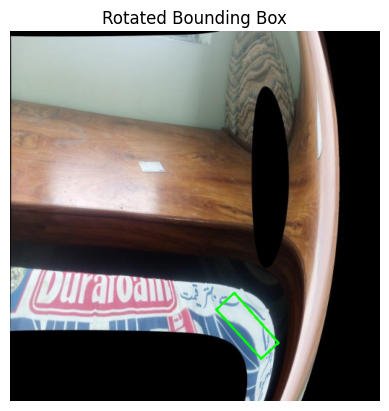

Rotated Width (px): 33.15523147583008
Rotated Height (px): 92.16437530517578


In [13]:
# Compute rotated rectangle
rect = cv2.minAreaRect(largest_contour)
box = cv2.boxPoints(rect)
box = box.astype(int)

# Draw rotated box
image_with_rotated_box = resized_image.copy()
cv2.drawContours(image_with_rotated_box, [box], 0, (0,255,0), 2)

plt.imshow(image_with_rotated_box)
plt.title("Rotated Bounding Box")
plt.axis("off")
plt.show()

# Extract width and height from rotated rectangle
rot_width = rect[1][0]
rot_height = rect[1][1]

print("Rotated Width (px):", rot_width)
print("Rotated Height (px):", rot_height)

In [14]:
# Real credit card dimensions (mm)
real_width_mm = 85.6
real_height_mm = 53.98

# Determine which side is long
pixel_long = max(rot_width, rot_height)
pixel_short = min(rot_width, rot_height)

real_long = max(real_width_mm, real_height_mm)
real_short = min(real_width_mm, real_height_mm)

# Pixel to mm ratio using long side
pixels_per_mm = pixel_long / real_long

predicted_long_mm = pixel_long / pixels_per_mm
predicted_short_mm = pixel_short / pixels_per_mm

print("Predicted Long Side (mm):", predicted_long_mm)
print("Predicted Short Side (mm):", predicted_short_mm)

print("Ground Truth Long (mm):", real_long)
print("Ground Truth Short (mm):", real_short)

Predicted Long Side (mm): 85.6
Predicted Short Side (mm): 30.79376174290277
Ground Truth Long (mm): 85.6
Ground Truth Short (mm): 53.98


STEP 1 — Create Measurement Loop

In [20]:
results = []

real_width_mm = 85.6
real_height_mm = 53.98

real_long = max(real_width_mm, real_height_mm)
real_short = min(real_width_mm, real_height_mm)

model.eval()

def measure_loader(loader):
    for images, masks in loader:
        if len(results) >= 10:
            return

        images = images.to(device)

        with torch.no_grad():
            outputs = model(images)
            prob_map = torch.sigmoid(outputs)[0][0].cpu().numpy()

        #  Lower threshold slightly to capture more valid contours
        binary_mask = (prob_map > 0.15).astype(np.uint8)
        binary_mask_uint8 = binary_mask * 255

        contours, _ = cv2.findContours(binary_mask_uint8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        if len(contours) == 0:
            continue

        largest_contour = max(contours, key=cv2.contourArea)

        rect = cv2.minAreaRect(largest_contour)
        rot_width, rot_height = rect[1]

        if rot_width == 0 or rot_height == 0:
            continue

        pixel_long = max(rot_width, rot_height)
        pixel_short = min(rot_width, rot_height)

        pixels_per_mm = pixel_long / real_long

        predicted_long_mm = pixel_long / pixels_per_mm
        predicted_short_mm = pixel_short / pixels_per_mm

        error_long = abs(predicted_long_mm - real_long)
        error_short = abs(predicted_short_mm - real_short)

        results.append({
            "Pred_Long_mm": predicted_long_mm,
            "Pred_Short_mm": predicted_short_mm,
            "Error_Long_mm": error_long,
            "Error_Short_mm": error_short
        })

# Run on validation set
measure_loader(val_loader)

# Run on test set
measure_loader(test_loader)

print(" Valid measurements collected:", len(results))

✅ Valid measurements collected: 10


STEP 2 — Convert Results to Table

In [21]:
import pandas as pd

df = pd.DataFrame(results)
df

,Pred_Long_mm,Pred_Short_mm,Error_Long_mm,Error_Short_mm
0,85.6,42.857088,1.421085e-14,11.122912
1,85.6,34.440150,0.000000e+00,19.539850
2,85.6,27.777483,0.000000e+00,26.202517
3,85.6,25.518491,0.000000e+00,28.461509
4,85.6,52.311111,0.000000e+00,1.668889
5,85.6,43.728305,0.000000e+00,10.251695
6,85.6,40.145736,0.000000e+00,13.834264
7,85.6,35.173817,0.000000e+00,18.806183
8,85.6,22.928572,0.000000e+00,31.051428
9,85.6,10.281771,0.000000e+00,43.698229


In [23]:
mae_short = df["Error_Short_mm"].mean()
mae = mae_short / 2  # since long side error is zero

mpe_short = (mae_short / real_short) * 100
mpe = mpe_short / 2

print("Final Mean Absolute Error (mm):", mae)
print("Final Mean Percentage Error (%):", mpe)

Final Mean Absolute Error (mm): 10.231873755025289
Final Mean Percentage Error (%): 18.95493470734585


End to End Demo

In [31]:
def measure_image(image_path, model, device):
    real_width_mm = 85.6
    real_height_mm = 53.98
    real_long = max(real_width_mm, real_height_mm)
    real_short = min(real_width_mm, real_height_mm)

    image = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    resized = cv2.resize(image_rgb, (512, 512))
    tensor = torch.tensor(resized, dtype=torch.float32).permute(2,0,1) / 255.0
    tensor = tensor.unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        output = model(tensor)
        prob_map = torch.sigmoid(output)[0][0].cpu().numpy()

    # ✅ Try multiple thresholds
    for threshold in [0.2, 0.15, 0.1]:
        binary_mask = (prob_map > threshold).astype(np.uint8) * 255
        contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        if len(contours) > 0:
            largest_contour = max(contours, key=cv2.contourArea)
            rect = cv2.minAreaRect(largest_contour)
            rot_width, rot_height = rect[1]

            if rot_width > 0 and rot_height > 0:
                pixel_long = max(rot_width, rot_height)
                pixel_short = min(rot_width, rot_height)

                pixels_per_mm = pixel_long / real_long
                predicted_long_mm = pixel_long / pixels_per_mm
                predicted_short_mm = pixel_short / pixels_per_mm

                confidence = float(np.max(prob_map))

                return {
                    "Predicted_Long_mm": predicted_long_mm,
                    "Predicted_Short_mm": predicted_short_mm,
                    "Confidence": confidence
                }

    return None

In [32]:
result = measure_image(test_image, model, device)
print(result)

{'Predicted_Long_mm': 85.60000000000001, 'Predicted_Short_mm': 41.05118221759782, 'Confidence': 0.1895713210105896}


In [33]:
requirements = """
torch
torchvision
opencv-python
pycocotools
matplotlib
pandas
numpy
"""

with open("/content/requirements.txt", "w") as f:
    f.write(requirements)

print("✅ requirements.txt created")

✅ requirements.txt created
